In [1]:
import pandas as pd

# Load CSV file
df = pd.read_csv("zomato_ratings.csv")

print("Original Dataset:\n")
print(df)

Original Dataset:

        Restaurant  user_rating
0          Dominos          4.2
1        Pizza Hut          4.5
2           Subway          4.1
3       McDonald's          4.3
4      Burger King          4.4
5              KFC          4.2
6  Barbeque Nation          4.6
7  La Pino'z Pizza          4.3
8         Tea Post          4.1
9     Special Cafe          9.8


In [2]:
# Calculate Q1 and Q3
Q1 = df["user_rating"].quantile(0.25)
Q3 = df["user_rating"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate Lower and Upper Limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

# Detect Outliers
outliers = df[(df["user_rating"] < lower_limit) |
              (df["user_rating"] > upper_limit)]

print("\nDetected Outliers:\n")
print(outliers)

print("\nIndices of Outliers:")
print(outliers.index.tolist())

Q1 : 4.2
Q3 : 4.475
IQR : 0.27499999999999947
Lower Limit : 3.787500000000001
Upper Limit : 4.887499999999999

Detected Outliers:

     Restaurant  user_rating
9  Special Cafe          9.8

Indices of Outliers:
[9]


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("swiggy_orders.csv")

print("Swiggy Orders Dataset:\n")
print(df)

Swiggy Orders Dataset:

   Order_ID Customer_Name       Restaurant  order_amount
0       101         Harsh         Domino's           250
1       102           Raj        Pizza Hut           320
2       103         Priya              KFC           280
3       104          Amit       McDonald's           450
4       105          Neha           Subway           390
5       106         Rohan      Burger King           500
6       107        Anjali        La Pino'z           270
7       108         Karan         Tea Post           350
8       109         Sneha  Barbeque Nation           420
9       110         Arjun         Domino's          5000


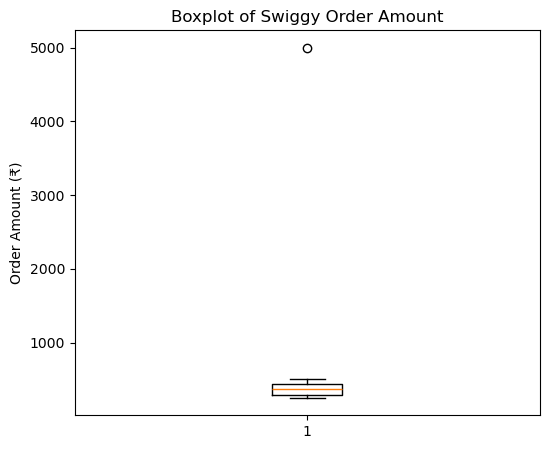

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.boxplot(df["order_amount"])

plt.title("Boxplot of Swiggy Order Amount")
plt.ylabel("Order Amount (₹)")

plt.show()

In [10]:
# Import pandas library
import pandas as pd

# Load Paytm transactions dataset
df = pd.read_csv("paytm_transactions.csv")

# Display the original dataset
print("Original Dataset:\n")
print(df)

Original Dataset:

   Transaction_ID User_Name  transaction_amount
0             101     Harsh                 250
1             102       Raj                 300
2             103     Priya                 450
3             104      Amit                 500
4             105      Neha                 550
5             106     Rohan                 600
6             107     Karan                 650
7             108     Sneha                 700
8             109    Anjali                 750
9             110     Arjun               10000


In [11]:
# Display summary statistics before Winsorization
print("Original Statistics:\n")
print(df["transaction_amount"].describe())

Original Statistics:

count       10.00000
mean      1475.00000
std       2999.74536
min        250.00000
25%        462.50000
50%        575.00000
75%        687.50000
max      10000.00000
Name: transaction_amount, dtype: float64


In [12]:
# Calculate the 5th percentile
lower_limit = df["transaction_amount"].quantile(0.05)

# Calculate the 95th percentile
upper_limit = df["transaction_amount"].quantile(0.95)

# Display percentile values
print("5th Percentile:", lower_limit)
print("95th Percentile:", upper_limit)

5th Percentile: 272.5
95th Percentile: 5837.49999999999


In [13]:
# Apply Winsorization by capping values
df["transaction_amount"] = df["transaction_amount"].clip(
    lower=lower_limit,
    upper=upper_limit
)

# Display updated transaction amounts
print("Updated Transaction Amount:\n")
print(df["transaction_amount"])

Updated Transaction Amount:

0     272.5
1     300.0
2     450.0
3     500.0
4     550.0
5     600.0
6     650.0
7     700.0
8     750.0
9    5837.5
Name: transaction_amount, dtype: float64


In [14]:
# Display summary statistics after Winsorization
print("Updated Statistics:\n")
print(df["transaction_amount"].describe())

Updated Statistics:

count      10.000000
mean     1061.000000
std      1685.673374
min       272.500000
25%       462.500000
50%       575.000000
75%       687.500000
max      5837.500000
Name: transaction_amount, dtype: float64


In [15]:
# Import pandas library
import pandas as pd

# Load CSV file
df = pd.read_csv("flipkart_products.csv")

# Display original dataset
print("Original Dataset:\n")
print(df)

Original Dataset:

   Product_ID        Product_Name    Price
0         101       Redmi Note 13  ₹12,999
1         102  Samsung Galaxy M35  ₹18,499
2         103     Realme Narzo 70  ₹15,999
3         104             iQOO Z9  ₹19,999
4         105            Moto G64  ₹14,499


In [16]:
# Check data types before conversion
print("Data Types Before Conversion:\n")
print(df.dtypes)

Data Types Before Conversion:

Product_ID       int64
Product_Name    object
Price           object
dtype: object


In [17]:
# Remove ₹ symbol and comma
df["Price"] = df["Price"].str.replace("₹", "", regex=False)
df["Price"] = df["Price"].str.replace(",", "", regex=False)

# Convert Price column to integer
df["Price"] = df["Price"].astype(int)

# Display updated dataset
print("Updated Dataset:\n")
print(df)

Updated Dataset:

   Product_ID        Product_Name  Price
0         101       Redmi Note 13  12999
1         102  Samsung Galaxy M35  18499
2         103     Realme Narzo 70  15999
3         104             iQOO Z9  19999
4         105            Moto G64  14499


In [18]:
# Check data types after conversion
print("Data Types After Conversion:\n")
print(df.dtypes)

Data Types After Conversion:

Product_ID       int64
Product_Name    object
Price            int64
dtype: object


In [19]:
# Import pandas library
import pandas as pd

# Create Spotify user dataset
data = {
    "User_ID": [101, 102, 103, 104, 105, 106, 107],
    "User_Name": ["Harsh", "Raj", "Priya", "Amit", "Neha", "Rohan", "Karan"],
    "is_premium": [True, "True", 1, "yes", False, 0, "No"]
}

df = pd.DataFrame(data)

# Display original dataset
print("Original Dataset:\n")
print(df)

Original Dataset:

   User_ID User_Name is_premium
0      101     Harsh       True
1      102       Raj       True
2      103     Priya          1
3      104      Amit        yes
4      105      Neha      False
5      106     Rohan          0
6      107     Karan         No


In [20]:
# Check data types before conversion
print("Data Types Before Conversion:\n")
print(df.dtypes)

Data Types Before Conversion:

User_ID        int64
User_Name     object
is_premium    object
dtype: object


In [21]:
# Convert mixed values to boolean
df["is_premium"] = df["is_premium"].apply(
    lambda x: str(x).strip().lower() in ["true", "1", "yes"]
)

# Display updated dataset
print("Updated Dataset:\n")
print(df)

Updated Dataset:

   User_ID User_Name  is_premium
0      101     Harsh        True
1      102       Raj        True
2      103     Priya        True
3      104      Amit        True
4      105      Neha       False
5      106     Rohan       False
6      107     Karan       False


In [22]:
# Check data types after conversion
print("Data Types After Conversion:\n")
print(df.dtypes)

Data Types After Conversion:

User_ID        int64
User_Name     object
is_premium      bool
dtype: object
